In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import joblib
import os
import json
from datetime import datetime
import re
import random
from imblearn.over_sampling import RandomOverSampler
from scipy.sparse import hstack  # To combine sparse matrices
from wordcloud import WordCloud
import sys
import sklearn
import xgboost

import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv('data/fin_data.csv', index_col=0)

In [11]:
df.head(10)

,original_statement,status,num_of_characters,num_of_sentences,statement,tokens,tokens_stemmed
0,oh my gosh,Anxiety,10,1,oh my gosh,"['oh', 'my', 'gosh']",oh my gosh
1,"trouble sleeping, confused mind, restless hear...",Anxiety,64,2,trouble sleeping confused mind restless heart ...,"['trouble', 'sleeping', 'confused', 'mind', 'r...",troubl sleep confus mind restless heart all ou...
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,78,2,all wrong back off dear forward doubt stay in ...,"['all', 'wrong', 'back', 'off', 'dear', 'forwa...",all wrong back off dear forward doubt stay in ...
3,I've shifted my focus to something else but I'...,Anxiety,61,1,ive shifted my focus to something else but im ...,"['ive', 'shifted', 'my', 'focus', 'to', 'somet...",ive shift my focu to someth els but im still w...
4,"I'm restless and restless, it's been a month n...",Anxiety,72,2,im restless and restless its been a month now ...,"['im', 'restless', 'and', 'restless', 'its', '...",im restless and restless it been a month now b...
5,"every break, you must be nervous, like somethi...",Anxiety,76,1,every break you must be nervous like something...,"['every', 'break', 'you', 'must', 'be', 'nervo...",everi break you must be nervou like someth is ...
6,"I feel scared, anxious, what can I do? And may...",Anxiety,78,2,i feel scared anxious what can i do and may my...,"['i', 'feel', 'scared', 'anxious', 'what', 'ca...",i feel scare anxiou what can i do and may my f...
7,Have you ever felt nervous but didn't know why?,Anxiety,47,1,have you ever felt nervous but didnt know why,"['have', 'you', 'ever', 'felt', 'nervous', 'bu...",have you ever felt nervou but didnt know whi
8,"I haven't slept well for 2 days, it's like I'm...",Anxiety,70,2,i havent slept well for 2 days its like im res...,"['i', 'havent', 'slept', 'well', 'for', '2', '...",i havent slept well for 2 day it like im restl...
9,"I'm really worried, I want to cry.",Anxiety,34,1,im really worried i want to cry,"['im', 'really', 'worried', 'i', 'want', 'to',...",im realli worri i want to cri


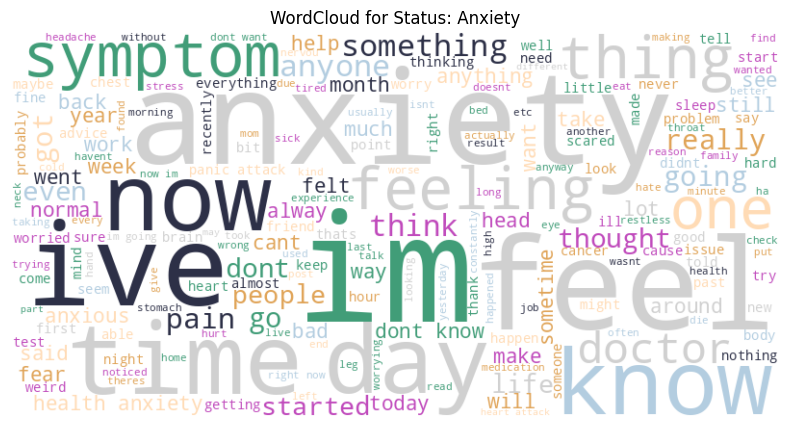

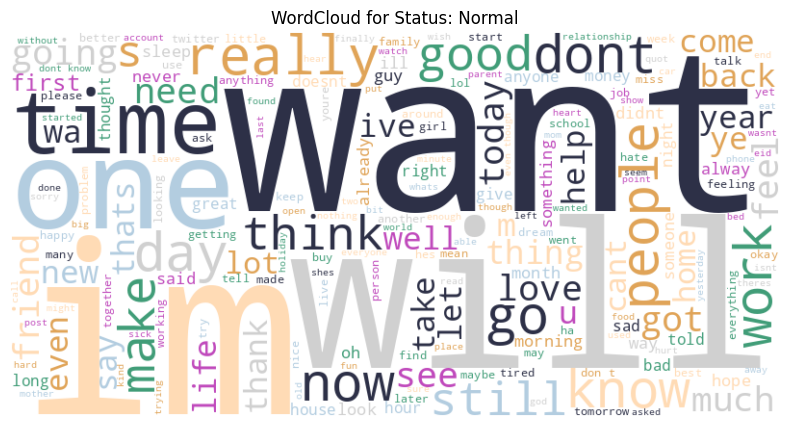

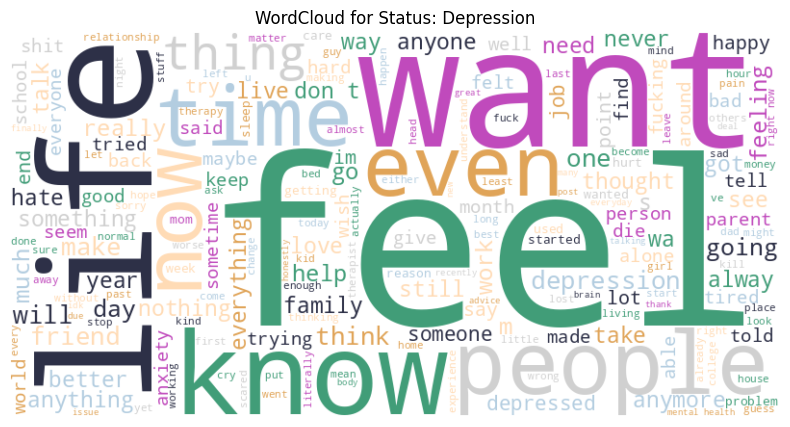

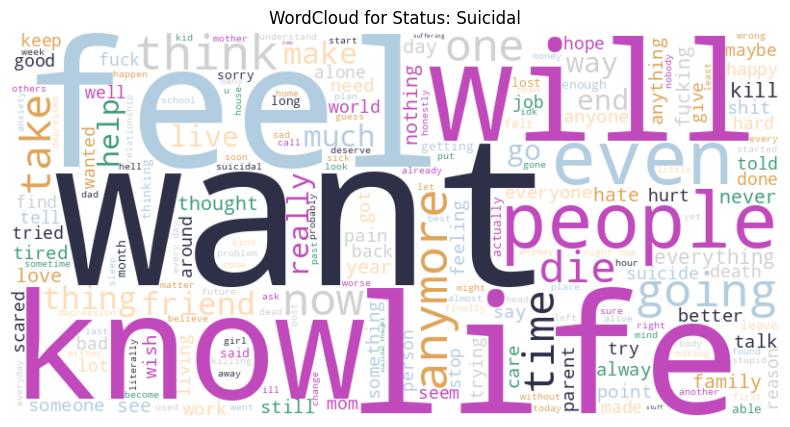

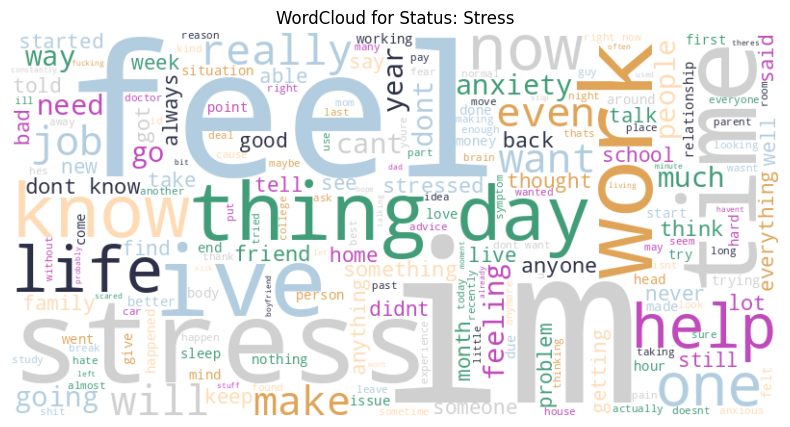

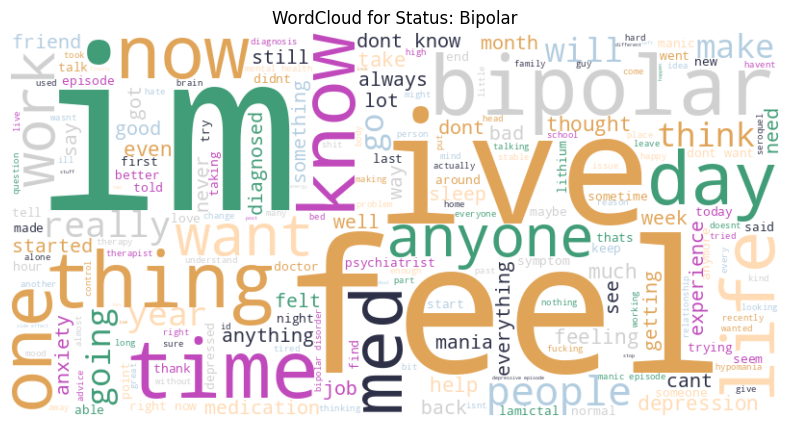

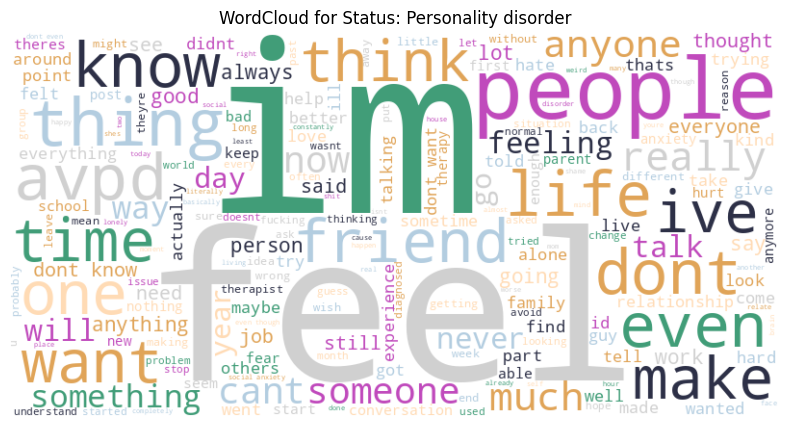

In [12]:
import ast
import random
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Преобразуем 'tokens' из строки в список (если нужно)
if isinstance(df['tokens'].iloc[0], str):
    df['tokens'] = df['tokens'].apply(ast.literal_eval)

# Цвета для wordcloud
colors = ['#419D78', '#E0A458', '#2D3047', '#FFDBB5', '#C04ABC', '#B3CDE0', '#D0D0D0']

# Get unique categories in 'status'
statuses = df['status'].unique()

# Define a color function
def color_func(word, font_size, position, orientation, random_state=101, **kwargs):
    return random.choice(colors)

# Generate and plot the WordCloud for each category
for status in statuses:
    # Filter the tokens data for the current status and combine all tokens
    tokens_data = ' '.join([
        word 
        for tokens in df[df['status'] == status]['tokens'].dropna() 
        for word in tokens  # Разворачиваем списки токенов
    ])
    
    # Generate the WordCloud
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color='white', 
        color_func=color_func
    ).generate(tokens_data)
    
    # Plot the WordCloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Turn off axis
    plt.title(f'WordCloud for Status: {status}')
    plt.show()

In [13]:
df.isna().sum()

original_statement    0
status                0
num_of_characters     0
num_of_sentences      0
statement             5
tokens                0
tokens_stemmed        5
dtype: int64

In [14]:
df = df.dropna().reset_index(drop=True)
df.columns

Index(['original_statement', 'status', 'num_of_characters', 'num_of_sentences',
       'statement', 'tokens', 'tokens_stemmed'],
      dtype='str')

In [15]:
X = df[['tokens_stemmed', 'num_of_characters', 'num_of_sentences']]
y = df['status']

In [30]:
X

,tokens_stemmed,num_of_characters,num_of_sentences
0,oh my gosh,10,1
1,troubl sleep confus mind restless heart all ou...,64,2
2,all wrong back off dear forward doubt stay in ...,78,2
3,ive shift my focu to someth els but im still w...,61,1
4,im restless and restless it been a month now b...,72,2
...,...,...,...
52671,nobodi take me serious ive 24m dealt with depr...,1766,16
52672,selfish i dont feel veri good it like i dont b...,1012,12
52673,is there ani way to sleep better i cant sleep ...,85,2
52674,public speak tip hi all i have to give a prese...,401,6


In [16]:
## 4.2. Label encoding target variable
lbl_enc = LabelEncoder()
y = lbl_enc.fit_transform(y.values)

In [17]:
## 4.3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)
X_train.columns

Index(['tokens_stemmed', 'num_of_characters', 'num_of_sentences'], dtype='str')

In [18]:
# 1. Initialize TF-IDF Vectorizer and fit/transform on the 'tokens' column
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train['tokens_stemmed'])
X_test_tfidf = vectorizer.transform(X_test['tokens_stemmed'])

In [19]:
# 2. Extract numerical features
X_train_num = X_train[['num_of_characters', 'num_of_sentences']].values
X_test_num = X_test[['num_of_characters', 'num_of_sentences']].values

In [20]:
# 3. Combine TF-IDF features with numerical features
X_train_combined = hstack([X_train_tfidf, X_train_num])
X_test_combined = hstack([X_test_tfidf, X_test_num])

In [21]:
# Применяем PCA к TF-IDF (уменьшаем до 1000 компонент)
pca = PCA(n_components=1000, random_state=101)
X_train_pca = pca.fit_transform(X_train_tfidf.toarray())
X_test_pca = pca.transform(X_test_tfidf.toarray())

# Добавляем числовые признаки
X_train_num = X_train[['num_of_characters', 'num_of_sentences']].values
X_test_num = X_test[['num_of_characters', 'num_of_sentences']].values

# Объединяем
X_train_combined = np.hstack([X_train_pca, X_train_num])
X_test_combined = np.hstack([X_test_pca, X_test_num])

print(f"Новое количество признаков: {X_train_combined.shape[1]}")

Новое количество признаков: 1002


Number of feature words:  5000
DATA VERIFICATION
X_train_resampled shape: (91504, 1002)
X_test_combined shape: (10536, 1002)
y_train_resampled shape: (91504,)
y_test shape: (10536,)
Number of classes: 7
Classes: [0 1 2 3 4 5 6]

Class distribution in train:
0    13072
1    13072
2    13072
3    13072
4    13072
5    13072
6    13072
Name: count, dtype: int64

Class distribution in test:
0     747
1     565
2    3060
3    3267
4     210
5     542
6    2145
Name: count, dtype: int64

Training: XGBoost

✅ Accuracy: 0.7778

Classification Report:
                      precision    recall  f1-score   support

             Anxiety       0.81      0.78      0.80       747
             Bipolar       0.83      0.75      0.79       565
          Depression       0.73      0.71      0.72      3060
              Normal       0.89      0.93      0.91      3267
Personality disorder       0.89      0.52      0.66       210
              Stress       0.67      0.75      0.70       542
            Suic

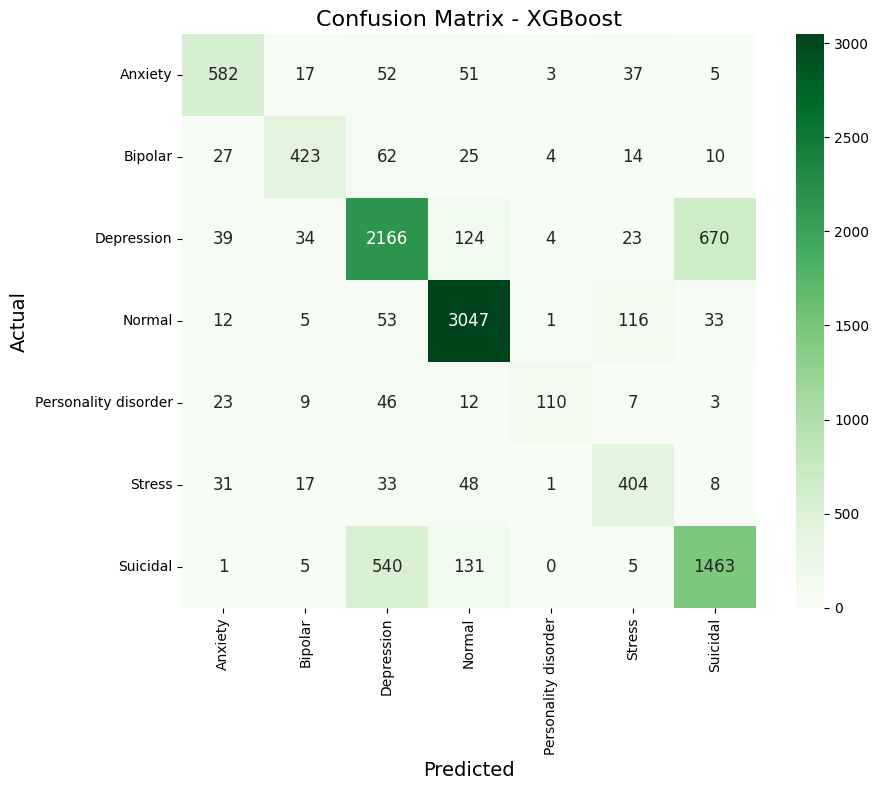


FINAL COMPARISON
Classifier  Accuracy
   XGBoost  0.777809


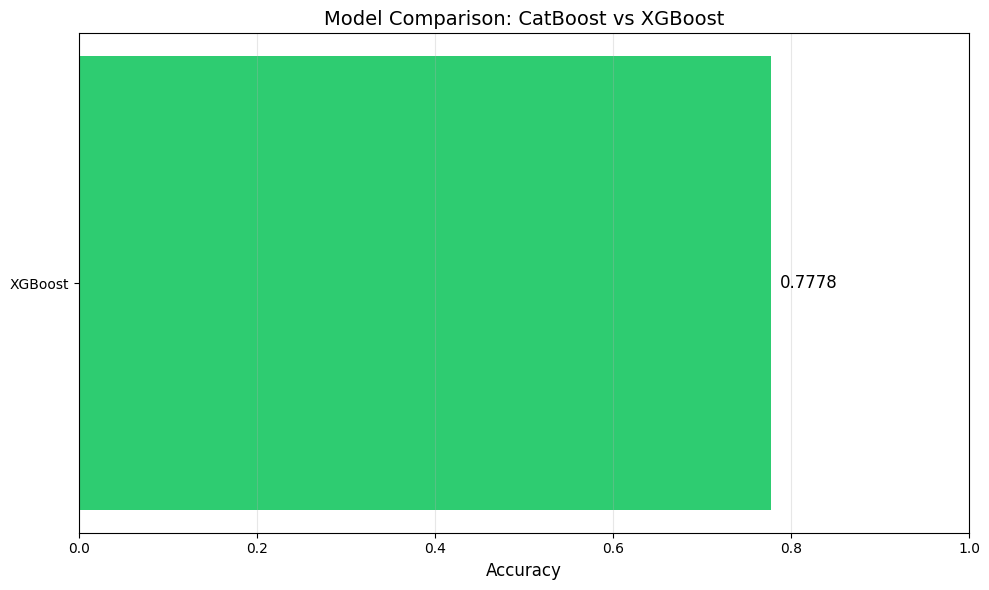


🏆 Лучшая модель: XGBoost с точностью 0.7778

ADDITIONAL ANALYSIS - BEST MODEL


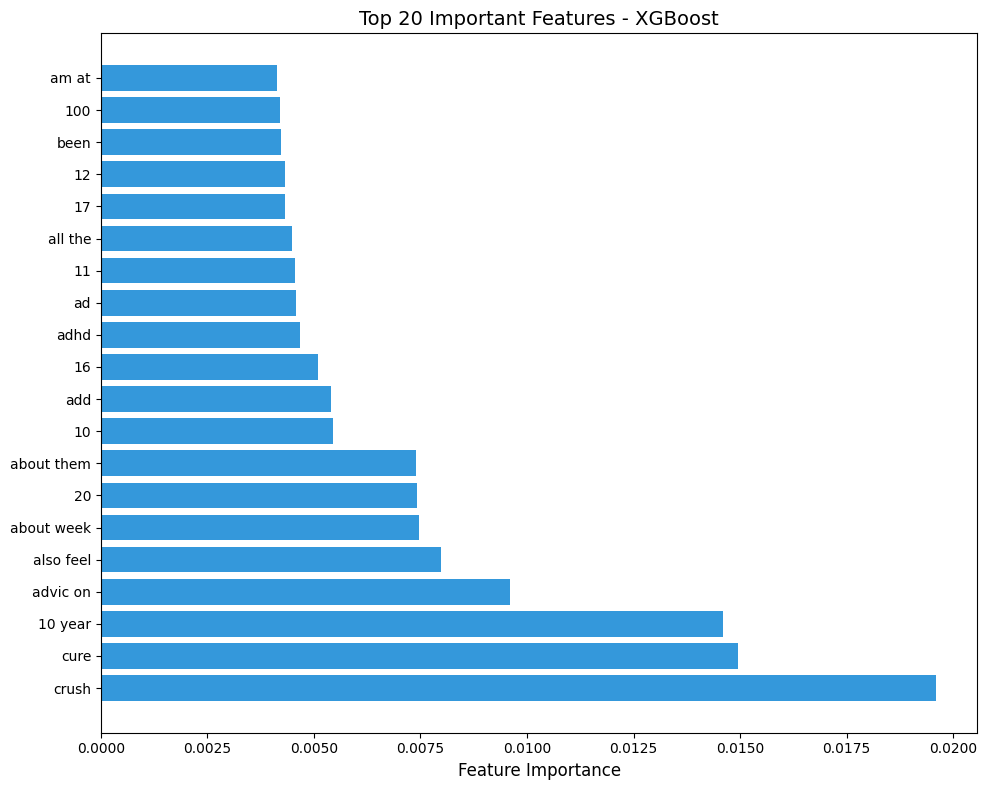


✅ Анализ завершен!


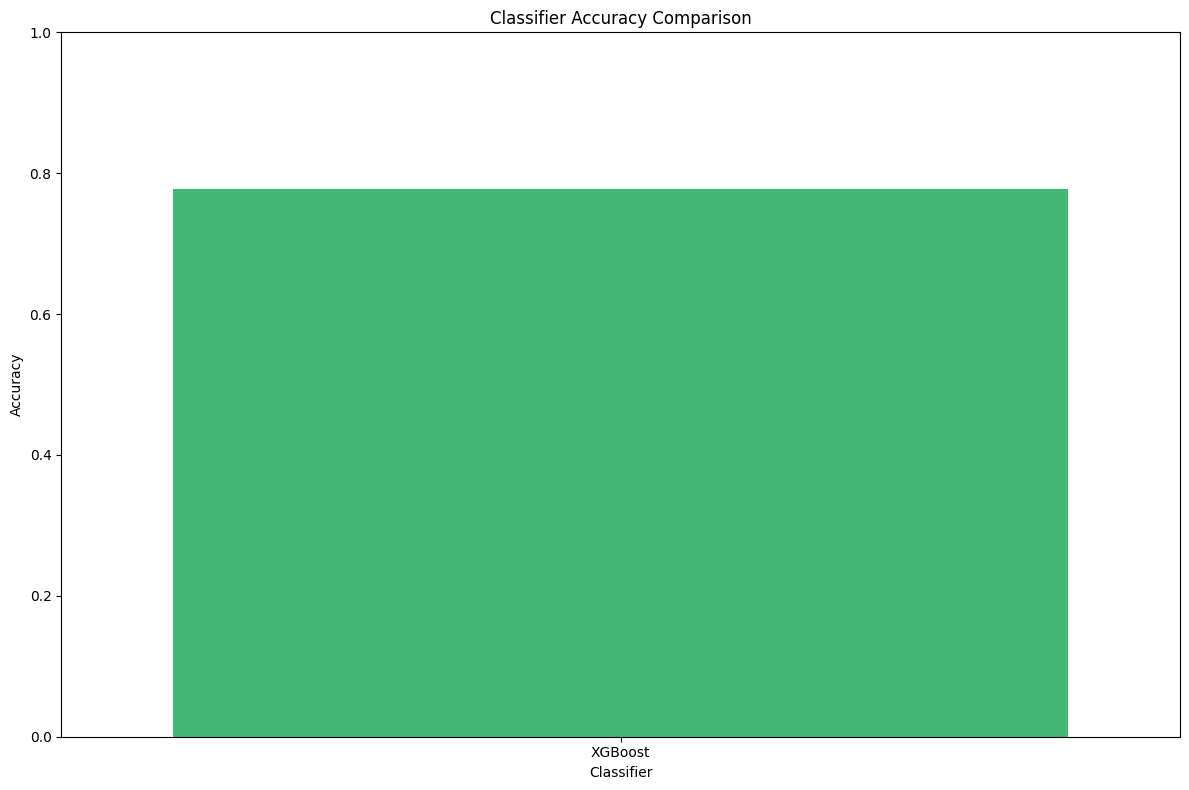

In [22]:


print('Number of feature words: ', len(vectorizer.get_feature_names_out()))
X_train_combined.shape
X_test_combined.shape
## 4.5. Resampling
# We experimented with various resampling techniques, including SMOTE, Random Over-Sampling and Random Under-Sampling. Among these, Random Over-Sampling provided the best results.
# Apply Random Over-Sampling on the vectorized data
ros = RandomOverSampler(random_state=101)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_combined, y_train)
X_train_resampled.shape


# ============= КЛАССИФИКАТОРЫ: XGBOOST =============
classifiers = {
    'XGBoost': XGBClassifier(
        n_estimators=500,         # количество деревьев
        learning_rate=0.1,        # скорость обучения
        max_depth=6,              # глубина деревьев
        random_state=101,
        use_label_encoder=False,  # отключаем устаревший label encoder
        eval_metric='mlogloss',   # метрика для многоклассовой классификации
        early_stopping_rounds=50, # ранняя остановка
        verbosity=1               # уровень вывода информации
    )
}

# ============= ПРОВЕРКА ДАННЫХ =============
print("="*60)
print("DATA VERIFICATION")
print("="*60)
print(f"X_train_resampled shape: {X_train_resampled.shape}")
print(f"X_test_combined shape: {X_test_combined.shape}")
print(f"y_train_resampled shape: {y_train_resampled.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Number of classes: {len(np.unique(y_train_resampled))}")
print(f"Classes: {np.unique(y_train_resampled)}")
print("\nClass distribution in train:")
print(pd.Series(y_train_resampled).value_counts().sort_index())
print("\nClass distribution in test:")
print(pd.Series(y_test).value_counts().sort_index())

# ============= ОБУЧЕНИЕ И ОЦЕНКА =============
accuracy_scores = []
results = []
models = {}

for name, clf in classifiers.items():
    print(f"\n{'='*60}")
    print(f"Training: {name}")
    print('='*60)

    try:
        # Для CatBoost нужны числовые метки классов
        # Преобразуем y в числовой формат, если это не так
        y_train_num = y_train_resampled
        y_test_num = y_test

        # Для XGBoost нужны числовые метки начиная с 0
        if name == 'XGBoost':
            # Если метки не начинаются с 0, преобразуем
            unique_classes = np.unique(y_train_resampled)
            if not np.array_equal(unique_classes, np.arange(len(unique_classes))):
                print(f"  Reindexing classes for {name}")
                class_map = {old: new for new, old in enumerate(unique_classes)}
                y_train_num = np.array([class_map[y] for y in y_train_resampled])
                y_test_num = np.array([class_map[y] for y in y_test])

        # Обучаем
        if name == 'CatBoost':
            clf.fit(
                X_train_resampled, y_train_num,
                eval_set=(X_test_combined, y_test_num),
                plot=False,
                verbose=100
            )
        else:  # XGBoost
            clf.fit(
                X_train_resampled, y_train_num,
                eval_set=[(X_test_combined, y_test_num)],
                verbose=False
            )

        # Предсказываем
        y_pred = clf.predict(X_test_combined)

        # Если метки были преобразованы, преобразуем обратно
        if name == 'XGBoost' and 'class_map' in locals():
            reverse_map = {v: k for k, v in class_map.items()}
            y_pred = np.array([reverse_map[p] for p in y_pred])
            y_test_num = y_test  # возвращаем оригинальные метки

        # Оценка
        accuracy = accuracy_score(y_test, y_pred)
        accuracy_scores.append(accuracy)

        print(f"\n✅ Accuracy: {accuracy:.4f}")

        # Classification report
        labels = lbl_enc.classes_
        print(f"\nClassification Report:")
        print(classification_report(y_test, y_pred, target_names=labels))

        # Confusion Matrix
        conf_matrix = confusion_matrix(y_test, y_pred)

        # Визуализация confusion matrix
        plt.figure(figsize=(10, 8))
        sns.heatmap(
            conf_matrix,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=labels,
            yticklabels=labels,
            annot_kws={'size': 12},
            square=True
        )
        plt.xlabel('Predicted', fontsize=14)
        plt.ylabel('Actual', fontsize=14)
        plt.title(f'Confusion Matrix - {name}', fontsize=16)
        plt.tight_layout()
        plt.show()

        # Сохраняем результат
        results.append({
            'Classifier': name,
            'Accuracy': accuracy,
            'Model': clf
        })
        models[name] = clf

    except Exception as e:
        print(f"❌ Error with {name}: {e}")
        import traceback
        traceback.print_exc()
        accuracy_scores.append(0)

# ============= СРАВНЕНИЕ МОДЕЛЕЙ =============
print("\n" + "="*60)
print("FINAL COMPARISON")
print("="*60)

comparison_df = pd.DataFrame({
    'Classifier': list(classifiers.keys()),
    'Accuracy': accuracy_scores
}).sort_values('Accuracy', ascending=False)

print(comparison_df.to_string(index=False))

# Визуализация сравнения
plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if i == 0 else '#3498db' for i in range(len(comparison_df))]
bars = plt.barh(comparison_df['Classifier'], comparison_df['Accuracy'], color=colors)
plt.xlabel('Accuracy', fontsize=12)
plt.title('Model Comparison: CatBoost vs XGBoost', fontsize=14)
plt.xlim(0, 1)
plt.grid(axis='x', alpha=0.3)

# Добавляем значения на бары
for bar, acc in zip(bars, comparison_df['Accuracy']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{acc:.4f}', va='center', fontsize=12)

plt.tight_layout()
plt.show()

# ============= ВЫВОД ЛУЧШЕЙ МОДЕЛИ =============
best_model = comparison_df.iloc[0]
print(f"\n🏆 Лучшая модель: {best_model['Classifier']} с точностью {best_model['Accuracy']:.4f}")

# ============= ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ ДЛЯ ЛУЧШЕЙ МОДЕЛИ =============
print("\n" + "="*60)
print("ADDITIONAL ANALYSIS - BEST MODEL")
print("="*60)

best_clf = models[best_model['Classifier']]

# Важность признаков (если доступна)
try:
    if best_model['Classifier'] == 'CatBoost':
        feature_importance = best_clf.feature_importances_
    else:  # XGBoost
        feature_importance = best_clf.feature_importances_

    # Получаем названия признаков (если есть)
    try:
        feature_names = vectorizer.get_feature_names_out() if hasattr(vectorizer, 'get_feature_names_out') else [f'feature_{i}' for i in range(len(feature_importance))]
    except:
        feature_names = [f'feature_{i}' for i in range(len(feature_importance))]

    # Топ-20 важных признаков
    top_n = min(20, len(feature_importance))
    top_indices = np.argsort(feature_importance)[-top_n:][::-1]
    top_features = [(feature_names[i], feature_importance[i]) for i in top_indices]

    plt.figure(figsize=(10, 8))
    features, importances = zip(*top_features)
    plt.barh(features, importances, color='#3498db')
    plt.xlabel('Feature Importance', fontsize=12)
    plt.title(f'Top {top_n} Important Features - {best_model["Classifier"]}', fontsize=14)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Could not show feature importance: {e}")

print("\n✅ Анализ завершен!")
# Create a DataFrame to store classifier names and their corresponding accuracy scores
accuracies_df = pd.DataFrame({'Classifier': classifiers.keys(), 'Accuracy': accuracy_scores}).sort_values('Accuracy', ascending=False)

plt.figure(figsize=(12, 8))
palette = dict(zip(accuracies_df['Classifier'], colors[:4]))

# Create a bar plot to visualize the accuracy of each classifier
sns.barplot(x='Classifier', y='Accuracy', data=accuracies_df, palette=palette)

plt.title("Classifier Accuracy Comparison")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

In [23]:
# Создаем структуру папок
models_dir = 'saved_models'  # общая папка для всех моделей
model_name = 'xgboost'       # название модели
model_path_full = os.path.join(models_dir, model_name)

# Создаем папки
if not os.path.exists(models_dir):
    os.makedirs(models_dir)
    print(f" Создана папка: {models_dir}")

if not os.path.exists(model_path_full):
    os.makedirs(model_path_full)
    print(f" Создана папка: {model_path_full}")

# Сохраняем модель XGBoost
model_file = os.path.join(model_path_full, 'xgboost_model.pkl')
joblib.dump(models['XGBoost'], model_file)
print(f" Модель сохранена: {model_file}")

# Сохраняем векторизатор
vectorizer_file = os.path.join(model_path_full, 'vectorizer.pkl')
joblib.dump(vectorizer, vectorizer_file)
print(f" Векторизатор сохранен: {vectorizer_file}")

# Сохраняем PCA (ВАЖНО! - этого не было в старом варианте)
pca_file = os.path.join(model_path_full, 'pca.pkl')
joblib.dump(pca, pca_file)
print(f" PCA сохранен: {pca_file}")

# Сохраняем label encoder
encoder_file = os.path.join(model_path_full, 'label_encoder.pkl')
joblib.dump(lbl_enc, encoder_file)
print(f" Label encoder сохранен: {encoder_file}")

# Сохраняем мета-информацию (обновленную с учетом PCA)
metadata = {
    'model_type': 'XGBoost',
    'accuracy': 0.7778,
    'classes': list(lbl_enc.classes_),
    'n_features': X_train_combined.shape[1],  # 1002 (1000 PCA + 2 числовых)
    'tfidf_max_features': 5000,
    'pca_components': 1000,
    'numerical_features': 2,
    'created_at': str(datetime.now()),
    'parameters': {
        'n_estimators': 500,
        'learning_rate': 0.1,
        'max_depth': 6,
        'random_state': 101
    }
}

metadata_file = os.path.join(model_path_full, 'metadata.json')
with open(metadata_file, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f"✅ Метаданные сохранены: {metadata_file}")

# Сохраняем информацию о версиях библиотек
versions = {
    'python': sys.version,
    'xgboost': xgboost.__version__,
    'scikit-learn': sklearn.__version__,
    'joblib': joblib.__version__
}

versions_file = os.path.join(model_path_full, 'versions.json')
with open(versions_file, 'w', encoding='utf-8') as f:
    json.dump(versions, f, ensure_ascii=False, indent=2)
print(f" Версии библиотек сохранены: {versions_file}")

print(f"\n Все файлы сохранены в: {model_path_full}")
print("\nСтруктура папок:")
print(f"{models_dir}/")
print(f"└── {model_name}/")
print(f"    ├── xgboost_model.pkl")
print(f"    ├── vectorizer.pkl")
print(f"    ├── pca.pkl               # ← НОВЫЙ ФАЙЛ!")
print(f"    ├── label_encoder.pkl")
print(f"    ├── metadata.json")
print(f"    └── versions.json")

 Модель сохранена: saved_models/xgboost/xgboost_model.pkl
 Векторизатор сохранен: saved_models/xgboost/vectorizer.pkl
 PCA сохранен: saved_models/xgboost/pca.pkl
 Label encoder сохранен: saved_models/xgboost/label_encoder.pkl
✅ Метаданные сохранены: saved_models/xgboost/metadata.json
 Версии библиотек сохранены: saved_models/xgboost/versions.json

 Все файлы сохранены в: saved_models/xgboost

Структура папок:
saved_models/
└── xgboost/
    ├── xgboost_model.pkl
    ├── vectorizer.pkl
    ├── pca.pkl               # ← НОВЫЙ ФАЙЛ!
    ├── label_encoder.pkl
    ├── metadata.json
    └── versions.json


In [24]:
def load_xgboost_model(model_dir='saved_models/xgboost'):
    """
    Загрузка сохраненной модели XGBoost и связанных объектов
    """
    
    # Загружаем модель
    model = joblib.load(os.path.join(model_dir, 'xgboost_model.pkl'))
    
    # Загружаем векторизатор
    vectorizer = joblib.load(os.path.join(model_dir, 'vectorizer.pkl'))
    
    # Загружаем PCA (ОБЯЗАТЕЛЬНО!)
    pca = joblib.load(os.path.join(model_dir, 'pca.pkl'))
    
    # Загружаем label encoder
    encoder = joblib.load(os.path.join(model_dir, 'label_encoder.pkl'))
    
    # Загружаем метаданные
    with open(os.path.join(model_dir, 'metadata.json'), 'r', encoding='utf-8') as f:
        metadata = json.load(f)
    
    print(f" Модель загружена: {metadata['model_type']}")
    print(f" Точность: {metadata['accuracy']:.4f}")
    print(f" Классы: {metadata['classes']}")
    print(f" Размерность признаков: {metadata['n_features']}")
    print(f" PCA компонент: {metadata.get('pca_components', 'не указано')}")
    
    return model, vectorizer, pca, encoder, metadata

# Использование
model, vectorizer, pca, encoder, metadata = load_xgboost_model('saved_models/xgboost')

 Модель загружена: XGBoost
 Точность: 0.7778
 Классы: ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Personality disorder', 'Stress', 'Suicidal']
 Размерность признаков: 1002
 PCA компонент: 1000


## Функция обработки текста

In [25]:
# Скачиваем ресурсы NLTK
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

stemmer = PorterStemmer()

def preprocess_text(text):
    """
    Предобработка текста (стеммирование)
    """
    if not isinstance(text, str):
        text = str(text)
    
    # Lowercasing
    text = text.lower()
    
    # Remove URLs, handles, punctuation
    text = re.sub(r'http[s]?://\S+', '', text)
    text = re.sub(r'\[.*?\]\(.*?\)', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Stemming
    stemmed_tokens = [stemmer.stem(token) for token in tokens]
    
    return ' '.join(stemmed_tokens)

def extract_features(text, vectorizer, pca, num_chars=None, num_sentences=None):
    """
    Полный pipeline извлечения признаков:
    1. Предобработка текста
    2. TF-IDF векторизация
    3. PCA уменьшение размерности
    4. Добавление числовых признаков
    
    Parameters:
    -----------
    text : str
        Текст для обработки
    vectorizer : TfidfVectorizer
        Обученный векторизатор
    pca : PCA
        Обученный PCA
    num_chars : int, optional
        Количество символов (если не указано, вычисляется)
    num_sentences : int, optional
        Количество предложений (если не указано, вычисляется)
    
    Returns:
    --------
    np.ndarray : Объединенные признаки (1002 измерения)
    """
    # 1. Предобработка текста
    processed_text = preprocess_text(text)
    
    # 2. TF-IDF векторизация
    tfidf_features = vectorizer.transform([processed_text])
    
    # 3. PCA уменьшение размерности
    pca_features = pca.transform(tfidf_features.toarray())
    
    # 4. Числовые признаки
    if num_chars is None:
        num_chars = len(text)
    if num_sentences is None:
        # Простое определение количества предложений
        num_sentences = len(re.findall(r'[.!?]+', text)) or 1
    
    numerical_features = np.array([[num_chars, num_sentences]])
    
    # 5. Объединение
    combined_features = np.hstack([pca_features, numerical_features])
    
    return combined_features

In [26]:
def predict_with_saved_model(text, model, vectorizer, pca, encoder, num_chars=None, num_sentences=None):
    """
    Предсказание с использованием сохраненной модели
    """
    from scipy.sparse import hstack
    
    # 1. Предобработка текста
    processed_text = preprocess_text(text)
    
    # 2. TF-IDF векторизация
    tfidf_features = vectorizer.transform([processed_text])
    
    # 3. PCA уменьшение размерности
    pca_features = pca.transform(tfidf_features.toarray())
    
    # 4. Числовые признаки
    if num_chars is None:
        num_chars = len(text)
    if num_sentences is None:
        num_sentences = len(re.findall(r'[.!?]+', text)) or 1
    
    numerical_features = np.array([[num_chars, num_sentences]])
    
    # 5. Объединение
    combined_features = np.hstack([pca_features, numerical_features])
    
    # 6. Проверка размерности
    if combined_features.shape[1] != model.n_features_in_:
        raise ValueError(f"Несоответствие признаков: получили {combined_features.shape[1]}, ожидаем {model.n_features_in_}")
    
    # 7. Предсказание
    prediction = model.predict(combined_features)
    prediction_proba = model.predict_proba(combined_features)
    
    # 8. Преобразуем метку
    predicted_class = encoder.inverse_transform(prediction)[0]
    
    # 9. Вероятности для всех классов
    probabilities = {
        encoder.inverse_transform([i])[0]: prob 
        for i, prob in enumerate(prediction_proba[0])
    }
    
    return predicted_class, probabilities


## Инференс

In [27]:

# Тестируем
test_text = "I feel bad and sad, I'm worried and can't sleep."
pred_class, probs = predict_with_saved_model(test_text, model, vectorizer, pca, encoder)

print(f"\n Текст: {test_text}")
print(f" Предсказание: {pred_class}")
print(f" Уверенность: {probs[pred_class]:.2%}")


 Текст: I feel bad and sad, I'm worried and can't sleep.
 Предсказание: Normal
 Уверенность: 71.90%
